<a href="https://colab.research.google.com/github/geopayme/AstroPhysics/blob/main/smartflow_colab_dashboard_with_charts-(with_fixes).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SmartFlow Reactor™ Full Kinetics Dashboard with Dynamic and Static Charts

In [ ]:
import pandas as pd
import plotly.graph_objs as go
import ipywidgets as widgets
from IPython.display import display, Markdown

In [16]:
# Upload the full kinetics CSV file
def upload_csv():
    from google.colab import files
    uploaded = files.upload()
    return pd.read_csv(list(uploaded.keys())[0])

df = upload_csv()

Saving SmartFlow_Combined_With_Thresholds.csv to SmartFlow_Combined_With_Thresholds (5).csv


In [17]:
# ✅ Final SmartFlow Plotting Code Using Only CSV Thresholds
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display, Markdown

# Extract thresholds
threshold_row = df_raw.iloc[0]
threshold_map = {}
for col in df_raw.columns:
    try:
        val = float(threshold_row[col])
        threshold_map[col] = val
    except:
        threshold_map[col] = None  # non-numeric threshold (like Time or Timestamp)

# Clean up data rows
df = df_raw.iloc[1:].copy()
if 'Timestamp_ISO8601' in df.columns:
    df = df.drop(columns=['Timestamp_ISO8601'])
df = df.apply(pd.to_numeric, errors='coerce')
df = df.dropna(axis=1, how='all')
df.reset_index(drop=True, inplace=True)

# ✅ Only use threshold from file (not from user input)
def plot_kinetics(parameter='PFAS_total_ngL'):
    threshold = threshold_map.get(parameter, None)

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=df['Time_minutes'], y=df[parameter],
                             mode='lines', name=parameter, line=dict(color='blue')))

    if threshold is not None:
        fig.add_hline(y=threshold, line=dict(color='red', dash='dash'))
        current_val = df[parameter].iloc[-1]
        status = "⚠️ Exceeds threshold!" if current_val > threshold else "✅ Within safe range"
        display(Markdown(f"### {status} (Final value: {current_val:.2f}, Threshold: {threshold})"))

    fig.update_layout(title=f'{parameter} Kinetics Over Time',
                      xaxis_title='Time (minutes)', yaxis_title=parameter.replace('_', ' '),
                      height=500)
    fig.show()

# Dropdown to select parameter (threshold is used automatically)
param_dropdown = widgets.Dropdown(
    options=[col for col in df.columns if col != 'Time_minutes'],
    value='PFAS_total_ngL',
    description='Parameter:',
    style={'description_width': 'initial'}
)

widgets.interact(plot_kinetics, parameter=param_dropdown);
;


interactive(children=(Dropdown(description='Parameter:', options=('PFAS_total_ngL', 'PFOS_ngL', 'PFOA_ngL', 'C…

''

## 📊 Static Chart Panel for All Parameters

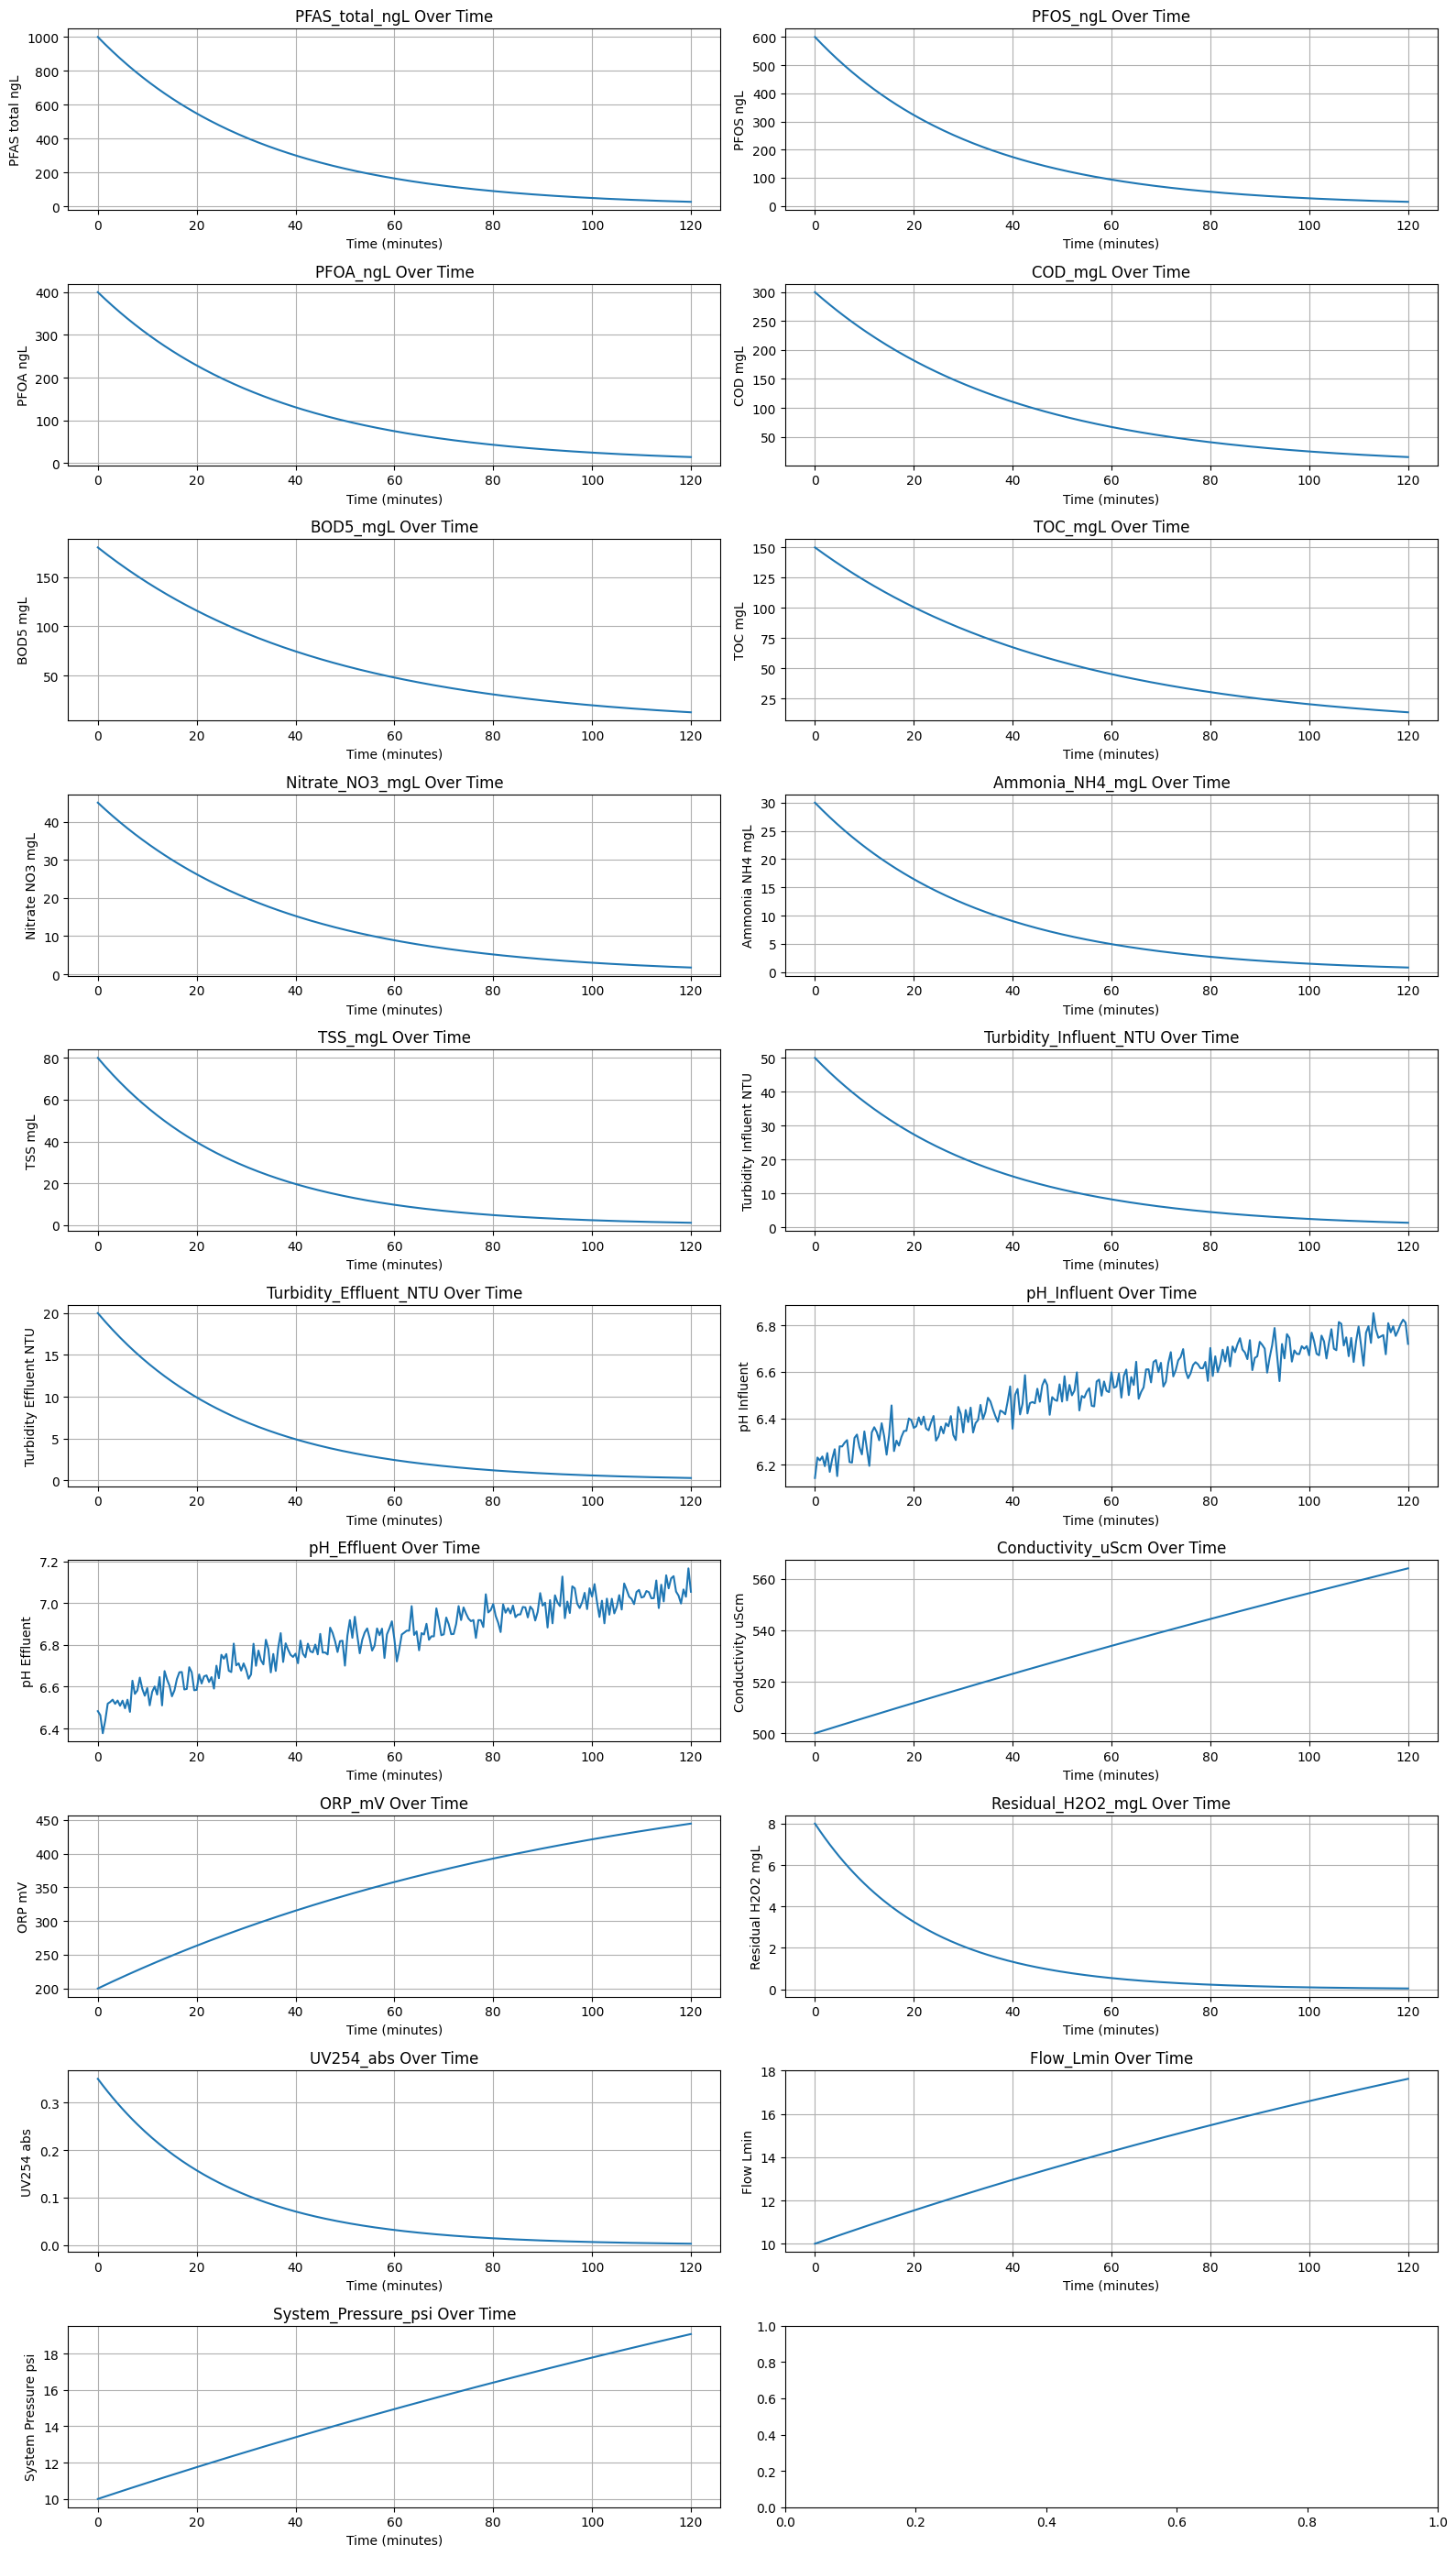

In [18]:

import matplotlib.pyplot as plt
import seaborn as sns

time = df['Time_minutes']
params = [col for col in df.columns if col != 'Time_minutes']

fig, axes = plt.subplots(nrows=len(params)//2 + 1, ncols=2, figsize=(16, 3 * len(params)//2))
axes = axes.flatten()

for idx, param in enumerate(params):
    sns.lineplot(x=time, y=df[param], ax=axes[idx])
    axes[idx].set_title(f'{param} Over Time')
    axes[idx].set_xlabel('Time (minutes)')
    axes[idx].set_ylabel(param.replace('_', ' '))
    axes[idx].grid(True)

plt.tight_layout()
plt.show()
